In [ ]:
# Step 1: Load dataset and inspect
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')

print("Features shape:", X.shape)
print("Class distribution:\n", y.value_counts())
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:\n", X.head())

Features shape: (150, 4)
Class distribution:
 target
0    50
1    50
2    50
Name: count, dtype: int64

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
from sklearn.model_selection import train_test_split

for col in X.columns:
    # convert to numeric if needed and fill NaNs with median
    X[col] = pd.to_numeric(X[col], errors='coerce')
    if X[col].isna().any():
        X[col] = X[col].fillna(X[col].median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())

Train shape: (120, 4) Test shape: (30, 4)
Train class distribution:
 target
0    40
2    40
1    40
Name: count, dtype: int64
Test class distribution:
 target
0    10
2    10
1    10
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("classification report\n:",classification_report(y_test, y_pred))

Accuracy: 0.9
Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]
classification report
:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [ ]:
fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(fi)

             feature  importance
3   petal width (cm)    0.437185
2  petal length (cm)    0.431466
0  sepal length (cm)    0.116349
1   sepal width (cm)    0.015000


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# quick OOB (out-of-bag) check
# (useful quick signal: set oob_score=True, bootstrap=True)

rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42, n_jobs=-1)
rf_oob.fit(X_train, y_train)
print("OOB score (quick check):", getattr(rf_oob, "oob_score_", None))

OOB score (quick check): 0.9416666666666667


In [ ]:
# Randomized search (recommended for speed)
param_dist = {
    'n_estimators': [100, 200, 400, 800],
    'max_depth': [None, 5, 10, 20, 40],
    'max_features': ['auto', 'sqrt', 'log2', 0.5],
    'min_samples_split': [2, 4, 8, 12],
    'min_samples_leaf': [1, 2, 4, 8],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,            # number of sampled parameter settings
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

In [ ]:
rs.fit(X_train, y_train)
print("\nRandomizedSearch best params:", rs.best_params_)
print("Best CV accuracy (mean):", rs.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits

RandomizedSearch best params: {'n_estimators': 100, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}
Best CV accuracy (mean): 0.9583333333333334


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

In [ ]:
# best estimator is refit on the whole X_train by default
rf_tuned = rs.best_estimator_

# Evaluate tuned model on test set
y_test_pred = rf_tuned.predict(X_test)
print("\nTest Accuracy (tuned):", accuracy_score(y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred, zero_division=0))


Test Accuracy (tuned): 0.9666666666666667

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
# Use GridSearchCV with a smaller grid (slower but thorough)
# grid = {
#     'n_estimators': [100,200],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2,4],
#     'min_samples_leaf': [1,2]
# }
# gs = GridSearchCV(RandomForestClassifier(random_state=42), grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
# gs.fit(X_train, y_train)
# print("GridSearch best:", gs.best_params_, gs.best_score_)

In [ ]:
model = rf_tuned

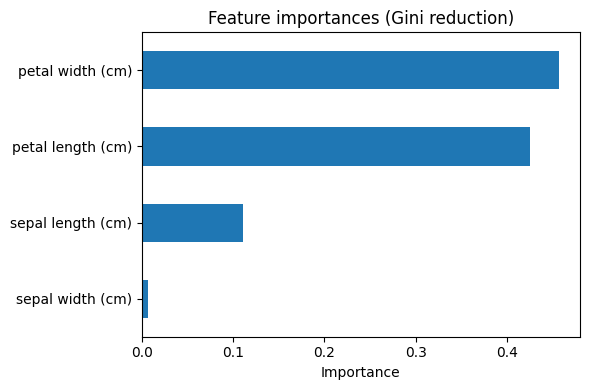

petal width (cm)     0.457018
petal length (cm)    0.425013
sepal length (cm)    0.110721
sepal width (cm)     0.007249
dtype: float64


In [ ]:
import matplotlib.pyplot as plt

fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(6,4))
fi.plot(kind='barh')
plt.title("Feature importances (Gini reduction)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
print(fi.sort_values(ascending=False))

In [ ]:
!pip install shap

In [ ]:
import shap

# Calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [26]:
# final_model is your trained RandomForest or best estimator

import joblib


joblib.dump(rf_tuned, "randomForest.joblib")
loaded = joblib.load("randomForest.joblib")
print("Loaded model test score:", loaded.score(X_test, y_test))

Loaded model test score: 0.9666666666666667


In [28]:
feature_names = list(X.columns)
new_sample = pd.DataFrame([[5.8, 2.7, 5.1, 1.9]], columns=feature_names)

In [29]:
pred_class = loaded.predict(new_sample)
pred_proba  = loaded.predict_proba(new_sample)        # prob per class

print("Numeric prediction:", pred_class[0])
print("Probabilities:", pred_proba[0])

Numeric prediction: 2
Probabilities: [0.         0.06003968 0.93996032]


In [30]:
iris = load_iris()
print("Predicted label:", iris.target_names[pred_class][0])

Predicted label: virginica
